In [ ]:
import numpy as np
import matplotlib.pyplot as plt

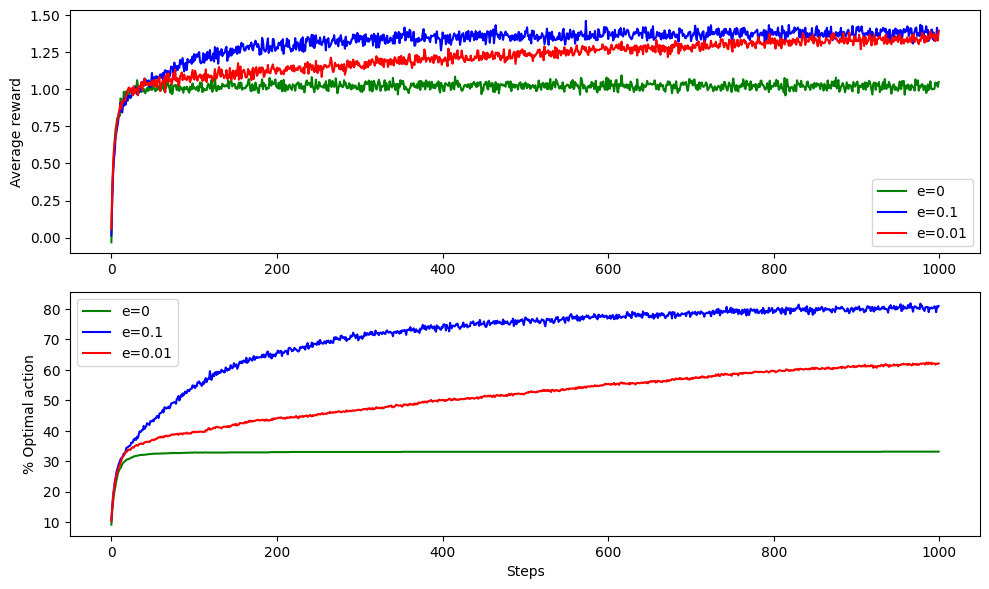

In [ ]:
def genBanditRewards():
    return np.random.normal(0, 1, 10)

def getCurrentReward(cKey, keysValues):
    return np.random.normal(keysValues[cKey], 1)

def runCycle(eu = 0):
    cBanditRewards = genBanditRewards()
    bestQ = np.argmax(cBanditRewards)

    Q = np.zeros(10)
    N = np.zeros(10)

    eulerRate = eu
    history = []

    for i in range(1000):
        cKey = np.random.choice(np.where(Q == np.max(Q))[0])
        randomV = np.random.uniform(0, 1)
        if randomV < eulerRate: #Aqui intentara uno aleatorio
            cKey = np.random.randint(0, 10)
        cReward = getCurrentReward(cKey, cBanditRewards)

        N[cKey] = N[cKey] + 1
        Q[cKey] = Q[cKey] + (1/N[cKey]) * (cReward - Q[cKey])

        isOptimal = (cKey == bestQ)
        history.append([cReward, isOptimal])
    return history

eulerRates = [0, 0.1, 0.01]
avgBank = []
pctBank = []

for e in eulerRates:
  total_rewards = np.zeros((2000, 1000))
  total_optimal = np.zeros((2000, 1000))

  for r in range(2000):
      res = runCycle(e)
      total_rewards[r] = [h[0] for h in res]
      total_optimal[r] = [h[1] for h in res]
  final_avg_rewards = np.mean(total_rewards, axis=0)
  final_pct_optimal = np.mean(total_optimal, axis=0) * 100

  avgBank.append(final_avg_rewards)
  pctBank.append(final_pct_optimal)


colores = ['green', 'blue', 'red']
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
for i, e in enumerate(eulerRates):
    plt.plot(avgBank[i], label=f'e={e}', color=colores[i])
plt.ylabel('Average reward')
plt.legend()

plt.subplot(2, 1, 2)
for i, e in enumerate(eulerRates):
    plt.plot(pctBank[i], label=f'e={e}', color=colores[i])
plt.ylabel('% Optimal action')
plt.xlabel('Steps')
plt.legend()

plt.tight_layout()
plt.show()

Codigo: https://colab.research.google.com/drive/1rnEiwSutrpVfnwfmMWKnCiKpIoUhjG5Z?authuser=1